In [3]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)
df = data.frame

print(df.shape)
print(df.describe())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

### Isolamento della colonna `AveOccup` e calcolo skewness

Osservando il `describe()` si può vedere come la media di `AveOccup` è ~3 ma il max arriva a 1243 — significa che ci sono pochissimi valori estremi che "tirano" la distribuzione verso destra, gonfiando la coda. 

In [ ]:

aveOcc = df['AveOccup']
print(aveOcc.skew())

#skew => vicino a 0 => distribuzione simmetrica

97.63956096369479


## Plotting di `AveOccup`

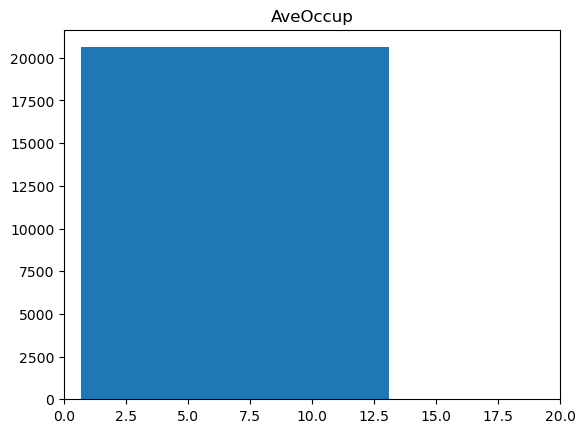

In [11]:
import matplotlib.pyplot as plt

plt.hist(aveOcc, bins=100)
plt.xlim(0,20)
plt.title('AveOccup')
plt.show()

Proviamo a fare un confronto compattando i valori tramite `np.log`

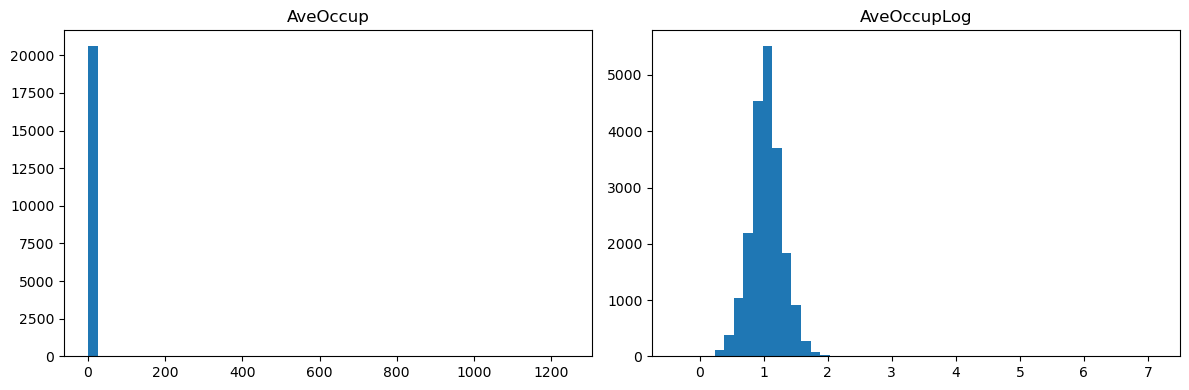

2.1275987743502807
10651.01063616739
34.63432236276538


In [14]:
aveOcc_log = np.log(aveOcc)

fig, (ax1,ax2) = plt.subplots( 1,2, figsize=(12,4))
ax1.hist(aveOcc, bins=50)
ax1.set_title('AveOccup')

ax2.set_title('AveOccupLog')
ax2.hist(aveOcc_log, bins=50)

plt.tight_layout()
plt.show()

print(aveOcc_log.skew())
print(aveOcc.kurt())                                                                                                                                                                                                       
print(aveOcc_log.kurt())

# Conclusioni

Alla luce dell'analisi effettuta sulla feature `AveOccup` possiamo dichiarare che la distribuzione dei dati soffriva di una coda pesante, dovuta alla presenza di outlier che rendevano estremamente asimmetrica la curva. 

A seguito di una compressione tramite `np.log` si è ottenuto una riduzione della coda e una diminuzione della *skew* e della *curtosi*

## Riepilogo analisi `AveOccup`                                                                                                                                                                                            
   
  | Metrica | Originale | Dopo log |                                                                                                                                                                                         
  |---------|-----------|----------|
  | Skewness | 97.6 | 2.12 |
  | Curtosi | 12418.43 | 34.64 |

  La feature `AveOccup` presenta una distribuzione fortemente asimmetrica con outlier estremi (max 1243 vs media 3).
  La trasformazione logaritmica riduce drasticamente skewness e curtosi, avvicinando la distribuzione a una gaussiana.